<a href="https://colab.research.google.com/github/Rajagopalhertzian/Rag_from_Scratch/blob/main/building_rag_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Document loaders

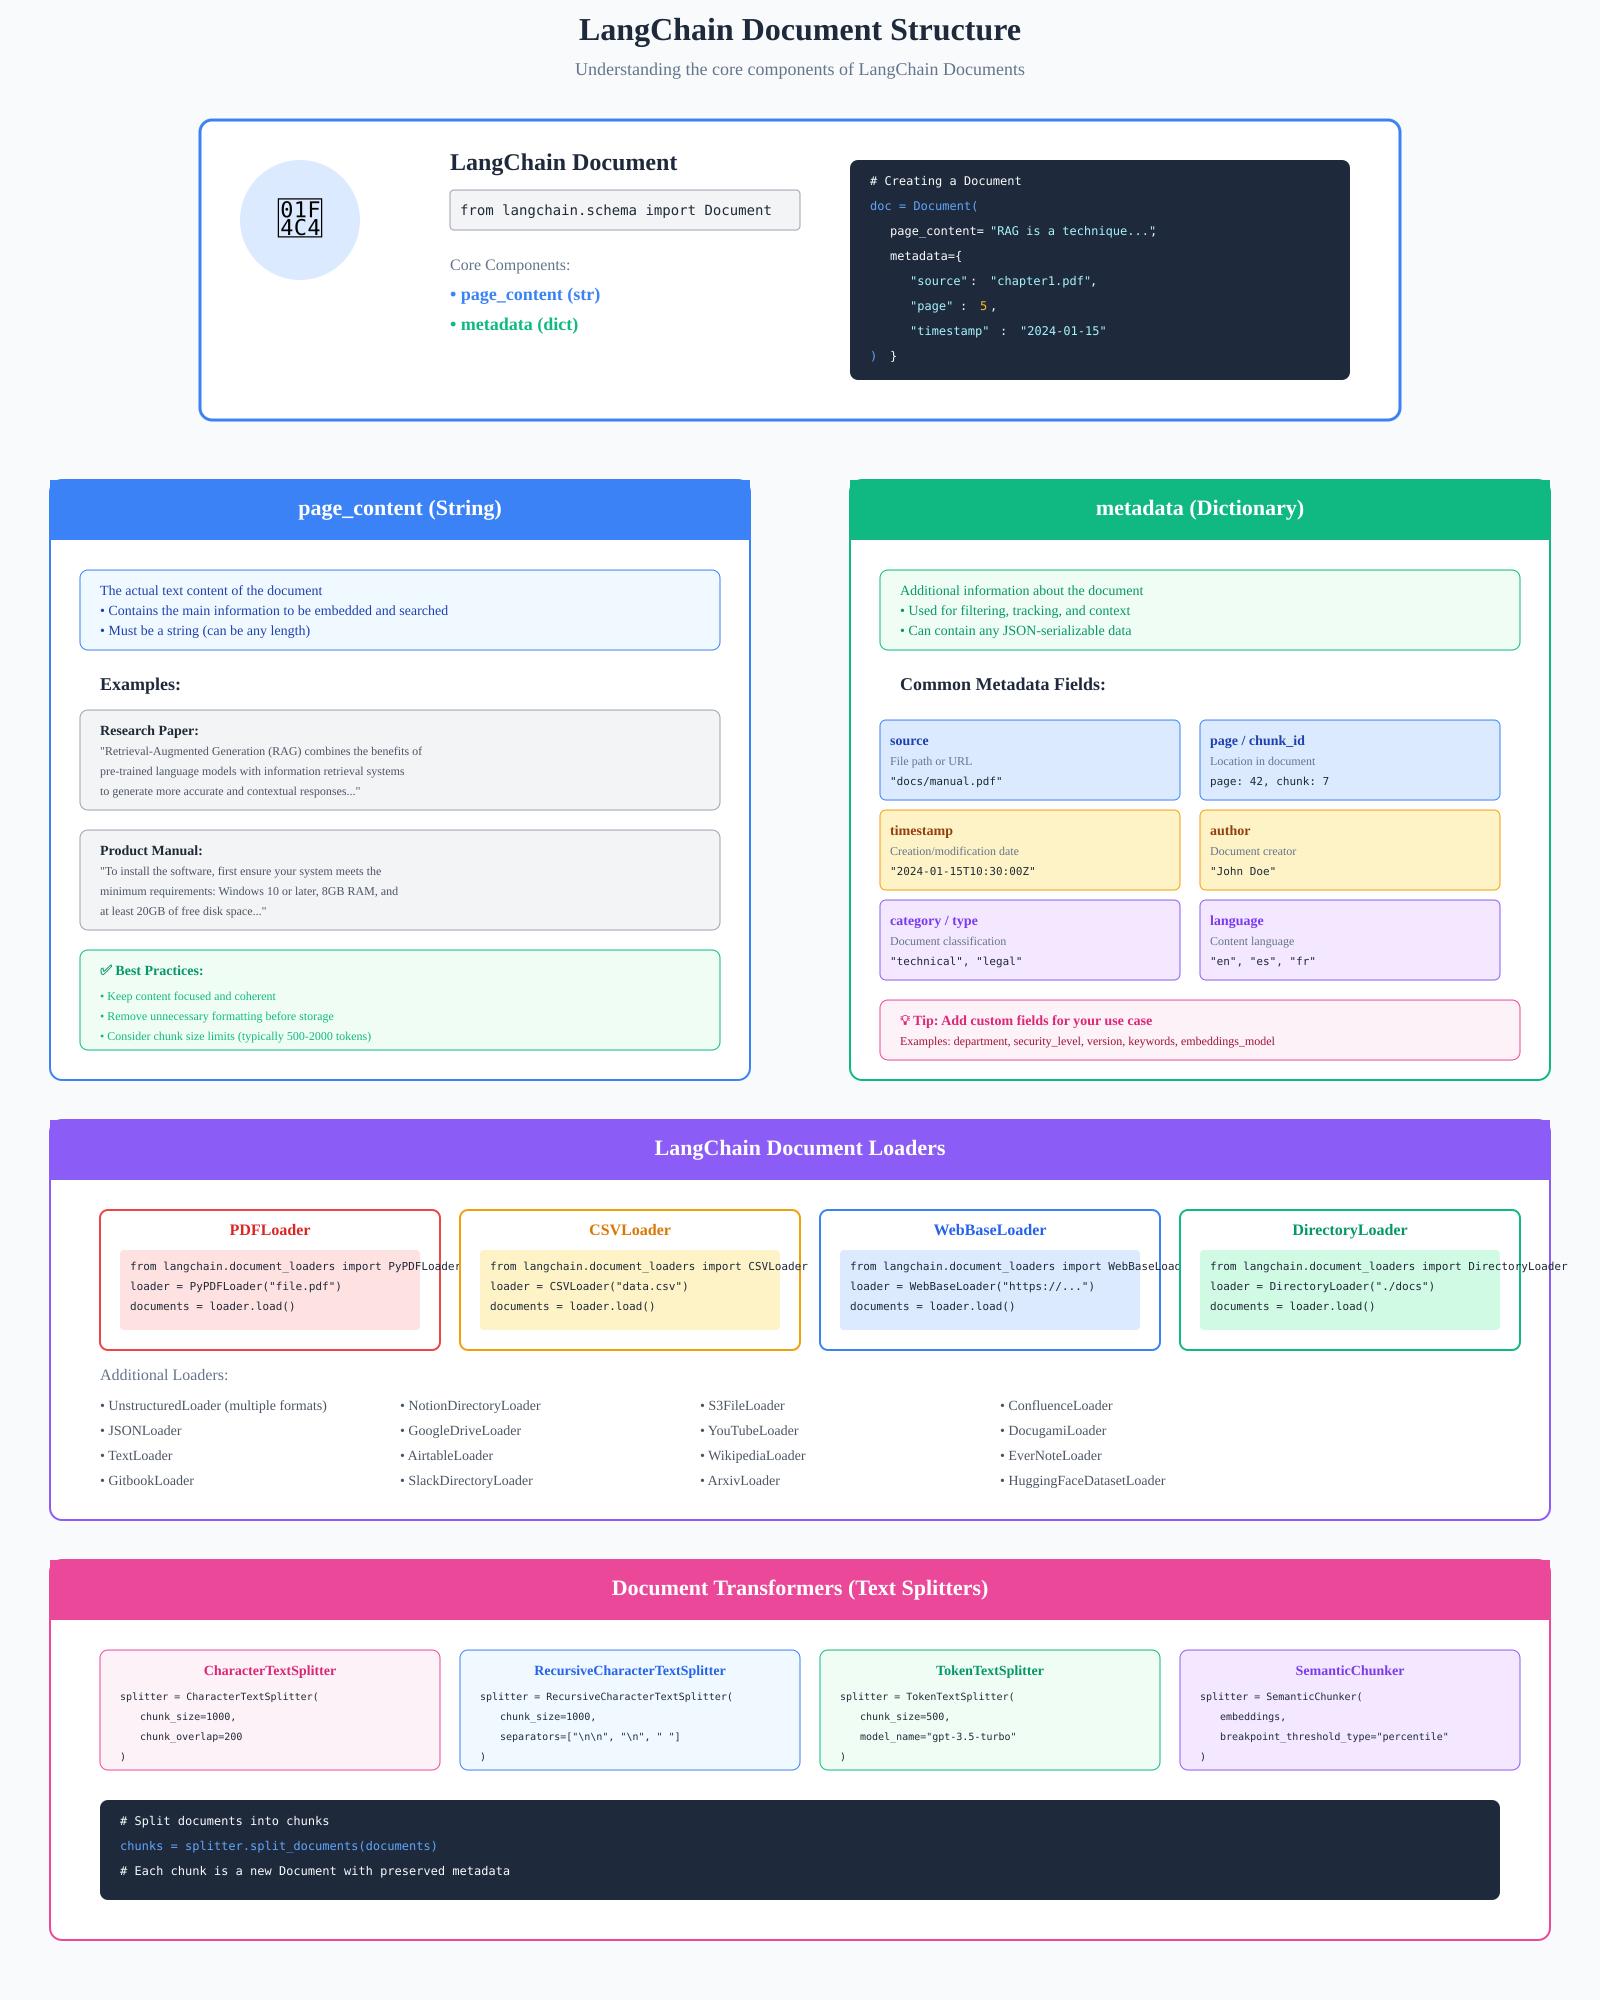

In [ ]:
from IPython.display import SVG, display

display(SVG("/content/1-langchain-document-components.svg"))

In [14]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 68.3 MB/s eta 0:00:00


In [9]:
pip list | grep langchain

langchain                                1.2.10
langchain-classic                        1.0.1
langchain-community                      0.4.1
langchain-core                           1.2.15
langchain-text-splitters                 1.1.1


In [5]:
from langchain_core.documents import Document


In [6]:
doc=Document('a document',metadata={'source':'Youtube'})

In [7]:
print(type(doc), '\n', 'here is the document', doc)

<class 'langchain_core.documents.base.Document'> 
 here is the document page_content='a document' metadata={'source': 'Youtube'}


In [8]:
import os

os.makedirs('/data/text_file',exist_ok=True)

In [9]:
sample={
    '/data/text_file/sample.txt':
    '''
    a sample data to create a text file
    for langchain document loaders   the document loaders are available in langchain_core.documnets
    ''',
    '/data/text_file/sample2.txt':'''this is sample 2 text file'''
}

for filepath,content in sample.items():
  with open(filepath,'w',encoding='utf-8') as f:
    f.write(content)

In [10]:
from langchain_community.document_loaders import TextLoader

In [11]:
loader=TextLoader('/data/text_file/sample.txt',encoding='utf-8')
doc=loader.load()
print(doc)

[Document(metadata={'source': '/data/text_file/sample.txt'}, page_content='\n    a sample data to create a text file\n    for langchain document loaders   the document loaders are available in langchain_core.documnets\n    ')]


In [12]:
# for loading directory

from langchain_community.document_loaders import DirectoryLoader

dir_loader=DirectoryLoader('/data/text_file',
                           glob='*.txt',
                           loader_cls=TextLoader,
                           loader_kwargs={'encoding':'utf-8'},
                           show_progress=True)
directory=dir_loader.load()
directory

100%|██████████| 2/2 [00:00<00:00, 1059.30it/s]


[Document(metadata={'source': '/data/text_file/sample2.txt'}, page_content='this is sample 2 text file'),
 Document(metadata={'source': '/data/text_file/sample.txt'}, page_content='\n    a sample data to create a text file\n    for langchain document loaders   the document loaders are available in langchain_core.documnets\n    ')]

In [29]:
# !pip install pymupdf

from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

dir=DirectoryLoader('/content/pdfs',
                    glob='*.pdf',
                    loader_cls=PyMuPDFLoader,
                    show_progress=True
                    )
pdf_doc=dir.load()
pdf_doc

100%|██████████| 2/2 [00:00<00:00, 11.61it/s]


[Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2013-09-10T00:03:46+00:00', 'source': '/content/pdfs/word2vec.pdf', 'file_path': '/content/pdfs/word2vec.pdf', 'total_pages': 12, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2013-09-10T00:03:46+00:00', 'trapped': '', 'modDate': 'D:20130910000346Z', 'creationDate': 'D:20130910000346Z', 'page': 0}, page_content='Efﬁcient Estimation of Word Representations in\nVector Space\nTomas Mikolov\nGoogle Inc., Mountain View, CA\ntmikolov@google.com\nKai Chen\nGoogle Inc., Mountain View, CA\nkaichen@google.com\nGreg Corrado\nGoogle Inc., Mountain View, CA\ngcorrado@google.com\nJeffrey Dean\nGoogle Inc., Mountain View, CA\njeff@google.com\nAbstract\nWe propose two novel model architectures for computing continuous vector repre-\nsentations of words from very large data sets. The quality of these representations\nis measured in a word similarity t

In [14]:
type(directory)

list

# Chunking

data ingestion to vector db

In [15]:
!pip install langchain langchain-text-splitters
import os
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [16]:
!pip install pypdf

In [30]:
#  read all pdf in the directory
from glob import glob
from langchain_community.document_loaders import PyPDFLoader
from pathlib import Path
def process_pdf_directory(pdf_directory):
  '''process the pdf in the directory'''

  all_documents=[]
  pdf_dir=Path(pdf_directory)

  pdf_files=list(pdf_dir.glob('*.pdf'))

  for pdf in pdf_files:
    try :
      loader = PyPDFLoader(str(pdf))
      document=loader.load()

      for doc in document:
        doc.metadata['source_file']=pdf.name
        doc.metadata['file_type']='pdf'

        all_documents.extend(document)
      print(len(document))

    except Exception as e:
        print(f"Error processing {pdf.name}: {e}")
  return all_documents

In [67]:
all_documents=process_pdf_directory('/content/pdfs')

12
12


In [32]:
all_documents

[Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2013-09-10T00:03:46+00:00', 'author': '', 'keywords': '', 'moddate': '2013-09-10T00:03:46+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/pdfs/word2vec.pdf', 'total_pages': 12, 'page': 0, 'page_label': '1', 'source_file': 'word2vec.pdf', 'file_type': 'pdf'}, page_content='Efﬁcient Estimation of Word Representations in\nVector Space\nTomas Mikolov\nGoogle Inc., Mountain View, CA\ntmikolov@google.com\nKai Chen\nGoogle Inc., Mountain View, CA\nkaichen@google.com\nGreg Corrado\nGoogle Inc., Mountain View, CA\ngcorrado@google.com\nJeffrey Dean\nGoogle Inc., Mountain View, CA\njeff@google.com\nAbstract\nWe propose two novel model architectures for computing continuous vector repre-\nsentations of words from very large data sets. The quality of these r

## Text splitting

In [66]:
print("Documents before splitting:", len(all_documents))

unique_docs = set(doc.page_content for doc in all_documents)
print("Unique documents before splitting:", len(unique_docs))

Documents before splitting: 288
Unique documents before splitting: 24


In [33]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_document(documents, chunk_size, chunk_overlap):

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=['\n\n', '\n', ' ', '']
    )

    split_docs = text_splitter.split_documents(documents)

    print(f"{len(documents)} documents split into {len(split_docs)} chunks")

    return split_docs

In [34]:
chunks=split_document(all_documents,1000,200)

288 documents split into 1440 chunks


# Embeddings and vector store

In [25]:
!pip install sentence_transformers
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Fou

 50%|█████     | 1/2 [02:47<02:47, 167.12s/it]


In [35]:
from sentence_transformers import SentenceTransformer

import chromadb
import numpy as np
from typing import List

class Embedding_Generator:

  def __init__(self,model_name: str = 'all-MiniLM-L6-v2'):
    self.model_name=model_name
    self.model=None
    self._load_model()

  def _load_model(self):

    try:
      self.model=SentenceTransformer(self.model_name)
      print(f'model loaded ith had dimension:{self.model.get_sentence_embedding_dimension()}')

    except Exception as e:
      print(f'error loading model:{e}')

  def generate_embedding(self,texts:List[str]) -> np.ndarray:
    if self.model is None:
      raise ValueError('model not loaded')
    print(f'generating embeddings for {len(texts)} texts')
    embeddings=self.model.encode(texts,show_progress_bar=True)
    return embeddings




In [36]:
# initialize embedding
embedding=Embedding_Generator()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model loaded ith had dimension:384


# vector store

In [37]:
print("All documents:", len(all_documents))
print("Chunks:", len(chunks))

All documents: 288
Chunks: 1440


In [40]:
from typing import List, Dict, Any
import uuid
class VectorStore:

    def __init__(self, collection_name: str = 'pdf_documents',
                 persistant_directory: str = '/data/vectorstore'):
        self.collection_name = collection_name
        self.persistant_directory = persistant_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        self.client = chromadb.PersistentClient(path=self.persistant_directory)
        self.collection = self.client.get_or_create_collection(
            name=self.collection_name
        )
        print(f"Vector store initialized at {self.persistant_directory}")
        print(f"Collection name: {self.collection_name}")

    def reset_collection(self):
        self.client.delete_collection(self.collection_name)
        self.collection = self.client.get_or_create_collection(
            name=self.collection_name
        )
        print("Collection reset.")

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):

        if len(documents) != len(embeddings):
            raise ValueError("Number of documents and embeddings must match")

        print(f"Adding {len(documents)} documents")

        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            doc_id = f'doc_{uuid.uuid4().hex[:8]}_{i}'
            ids.append(doc_id)

            metadata = dict(doc.metadata)
            metadatas.append(metadata)

            documents_text.append(doc.page_content)
            embeddings_list.append(embedding.tolist())

        self.collection.add(
            ids=ids,
            documents=documents_text,
            metadatas=metadatas,
            embeddings=embeddings_list
        )

In [41]:
vectorstore = VectorStore()
vectorstore.reset_collection()

embeddings = embedding.generate_embedding(
    [doc.page_content for doc in chunks]
)

vectorstore.add_documents(chunks, embeddings)

print("Vector count:", vectorstore.collection.count())

Vector store initialized at /data/vectorstore
Collection name: pdf_documents
Collection reset.
generating embeddings for 1440 texts


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Adding 1440 documents
Vector count: 1440


In [53]:
from typing import List, Dict, Any


class RAGRetriever:
    """Handles query-based retrieval from the vector store"""

    def __init__(self, vector_store: VectorStore, embedding_manager: Embedding_Generator):
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(
        self,
        query: str,
        top_k,
        distance_threshold: float = None
    ) -> List[Dict[str, Any]]:

        print(f"\nRetrieving documents for query: '{query}'")
        print(f"Top K: {top_k}")

        query_embedding = self.embedding_manager.generate_embedding([query])[0]

        results = self.vector_store.collection.query(
            query_embeddings=[query_embedding.tolist()],
            n_results=top_k
        )

        retrieved_docs = []

        documents = results.get("documents", [[]])[0]
        metadatas = results.get("metadatas", [[]])[0]
        distances = results.get("distances", [[]])[0]
        ids = results.get("ids", [[]])[0]

        if not documents:
            print("No documents returned from vector store.")
            return []

        for i, (doc_id, document, metadata, distance) in enumerate(
            zip(ids, documents, metadatas, distances)
        ):



            if distance_threshold is not None:
                if distance > distance_threshold:
                    continue

            retrieved_docs.append({
                "id": doc_id,
                "content": document,
                "metadata": metadata,
                "distance": distance,
                "rank": i + 1
            })

        print(f"Retrieved {len(retrieved_docs)} documents")
        return retrieved_docs

In [57]:
print("Total chunks:", len(chunks))

unique_contents = set(doc.page_content for doc in chunks)
print("Unique chunk texts:", len(unique_contents))

Total chunks: 1440
Unique chunk texts: 120


In [65]:
rag_retriever = RAGRetriever(vectorstore, embedding)

results = rag_retriever.retrieve("vector",1)

for r in results:
    print(r["rank"], r["distance"])
    print(r["content"][:200])
    print("-" * 50)


Retrieving documents for query: 'vector'
Top K: 1
generating embeddings for 1 texts


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieved 1 documents
1 1.2943509817123413
resulting vectors can be used to answer very subtle semantic relationships between words, such as
a city and the country it belongs to, e.g. France is to Paris as Germany is to Berlin. Word vectors
wi
--------------------------------------------------


In [77]:
!python i.py

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py", line 169, in read
    buf = fp.read()
          ^^^^^^^
AttributeError: 'str' object has no attribute 'read'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/i.py", line 3, in <module>
    nb = nbformat.read("building_rag_from_scratch.ipynb", as_version=4)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py", line 171, in read
    with open(fp, encoding="utf8") as f:  # noqa: PTH123
         ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'building_rag_from_scratch.ipynb'


In [48]:
! pip install langchain_groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00


In [49]:
%%writefile .env
GROQ_API_KEY='api key'


Writing .env


In [50]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

llm=ChatGroq(model='llama-3.1-8b-instant',temperature=0.1,max_tokens=1024)

In [52]:
llm.invoke('vector space').content

'A vector space is a fundamental concept in mathematics, particularly in linear algebra and geometry. It is a mathematical structure that consists of a set of vectors, which can be added together and scaled (multiplied by numbers) in a way that satisfies certain properties.\n\n**Definition:**\n\nA vector space is a set V together with two operations:\n\n1. **Vector addition**: a binary operation that takes two vectors u and v in V and produces another vector u + v in V.\n2. **Scalar multiplication**: a binary operation that takes a vector v in V and a scalar c (a number) and produces another vector cv in V.\n\n**Properties:**\n\nThe vector space must satisfy the following properties:\n\n1. **Closure under addition**: For any two vectors u and v in V, the sum u + v is also in V.\n2. **Commutativity of addition**: For any two vectors u and v in V, u + v = v + u.\n3. **Associativity of addition**: For any three vectors u, v, and w in V, (u + v) + w = u + (v + w).\n4. **Existence of additi

In [69]:
# rag function

def Rag(query,retriever,llm,top_k):
  results=retriever.retrieve(query,top_k=top_k)
  context ='\n\n'.join([doc['content'] for doc in results ]) if results else ""
  if not context:
    return 'no relevant context'
  prompt=f'''use the following context to answer the question consisely
          context:{context}
          question:{query}

          Answer:'''
  response=llm.invoke([prompt.format(context=context,query=query)])
  return response.content




In [71]:
answer=Rag('blip',rag_retriever,llm,1)
print(answer)


Retrieving documents for query: 'blip'
Top K: 1
generating embeddings for 1 texts


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieved 1 documents
BLIP: Bootstrapping Language-Image Pre-training for Uniﬁed Vision-Language Understanding and Generation.


In [74]:
def rag_advanced(query, retriever, llm, top_k=5, min_score=None, return_context=False):

    results = retriever.retrieve(
        query,
        top_k=top_k,
        distance_threshold=min_score
    )

    if not results:
        return {
            'answer': 'No relevant context found.',
            'sources': [],
            'confidence': 0.0,
            'context': ''
        }

    context = "\n\n".join([doc['content'] for doc in results])

    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'preview': doc['content'][:120] + "..."
    } for doc in results]

    confidence = 1 - results[0]['distance']

    prompt = f"""Use the following context to answer the question concisely.

Context:
{context}

Question:
{query}

Answer:"""

    response = llm.invoke(prompt)

    return {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence,

    }

In [75]:
answer=rag_advanced('blip',rag_retriever,llm,1)
print(answer)


Retrieving documents for query: 'blip'
Top K: 1
generating embeddings for 1 texts


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieved 1 documents
{'answer': 'BLIP: Bootstrapping Language-Image Pre-training for Uniﬁed Vision-Language Understanding and Generation.', 'sources': [{'source': 'blip.pdf', 'page': 4, 'preview': 'BLIP: Bootstrapping Language-Image Pre-training for Uniﬁed Vision-Language Understanding and Generation\nPre-train\ndatase...'}], 'confidence': -0.2797427177429199}
